In [ ]:
#DSO Project 3
#Shivi Anand, Edvina Buyuksoy
#Dataset:Power Consumption

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
# read the data into a df and learn about columns, dtypes, etc.
power_df = pd.read_csv('powerconsumption.csv')
power_df.info()
power_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
#Convert to datetime format and set index
power_df['Datetime'] = pd.to_datetime(power_df['Datetime'])
power_df = power_df.set_index('Datetime')

#Resample from 10-minute data to daily
daily_avg = power_df.resample('D').mean()

In [ ]:
# Function to check if data is stationary (directly copied from in class example code)
# This function will be later used
def check_stationarity(series):
    result = adfuller(series.values)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

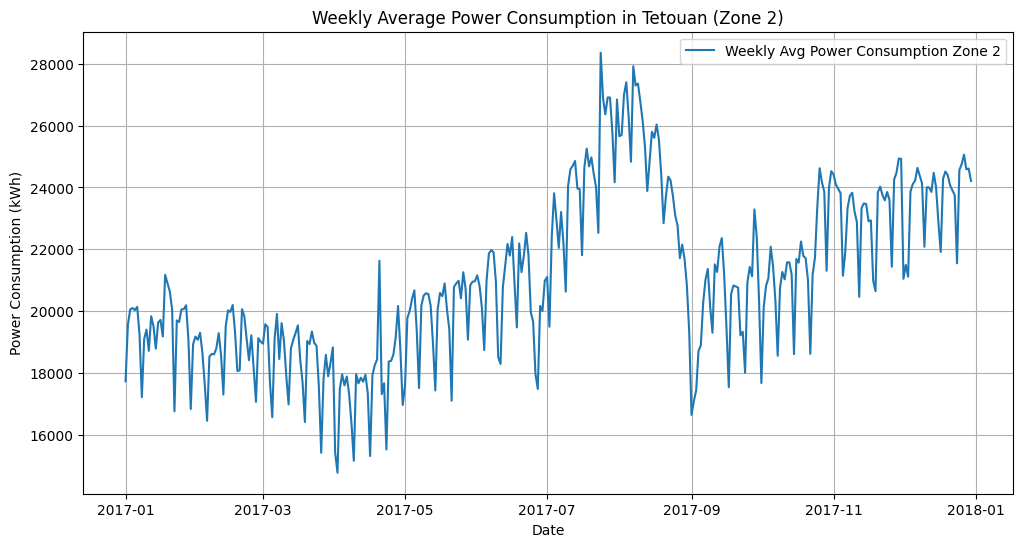

In [ ]:
# original series visualization
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg['PowerConsumption_Zone2'], label='Weekly Avg Power Consumption Zone 2')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.title('Weekly Average Power Consumption in Tetouan (Zone 2)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# running the stationarity function on the data
check_stationarity(daily_avg['PowerConsumption_Zone2'])

ADF Statistic: -1.525507
p-value: 0.520858
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571
Non-stationary


In [ ]:
# apply first level differencing
power_df = daily_avg['PowerConsumption_Zone2'].diff().dropna()

#checking stationarity after differencing
print("After First Differencing Stationarity Check")
check_stationarity(power_df)

After First Differencing Stationarity Check
ADF Statistic: -4.879325
p-value: 0.000038
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571
Stationary


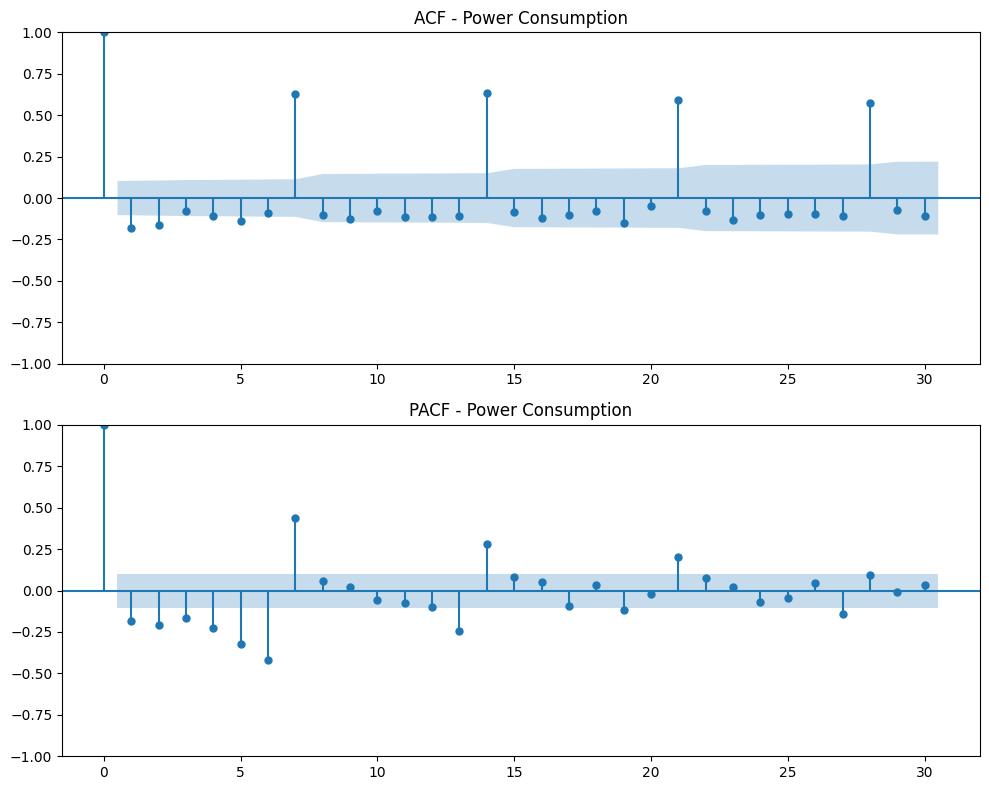

In [ ]:
#setting parameters for the acf and pacf visalizations
lag_acf =30
lag_pacf =30
height, width = 4, 10

#plotting pacf for AR and acf for MA
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2 * height))
plot_acf(power_df, lags=lag_acf, ax=ax[0])
ax[0].set_title('ACF - Power Consumption')
plot_pacf(power_df, lags=lag_pacf, ax=ax[1], method='ols')
ax[1].set_title('PACF - Power Consumption')
plt.tight_layout()
plt.show()

In [ ]:
#interpreting the ACF and PACF for orders of q and p respectively
# ACF, used for q = 7
# PACF, used for p = 7
# Differencing, d = 1 (as a result of the stationarity tests)

In [ ]:
#split into train and test
train_len = int(0.8 * len(daily_avg))
train = daily_avg['PowerConsumption_Zone2'][:train_len]
test = daily_avg['PowerConsumption_Zone2'][train_len:]

                              AutoReg Model Results                               
Dep. Variable:     PowerConsumption_Zone2   No. Observations:                  291
Model:                         AutoReg(7)   Log Likelihood               -2396.715
Method:                   Conditional MLE   S.D. of innovations           1119.007
Date:                    Tue, 14 Oct 2025   AIC                           4811.429
Time:                            22:06:58   BIC                           4844.270
Sample:                        01-08-2017   HQIC                          4824.596
                             - 10-18-2017                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       614.0861    563.464      1.090      0.276    -490.282    1718.455
PowerConsumption_Zone2.L1     0.5120      0.055      9

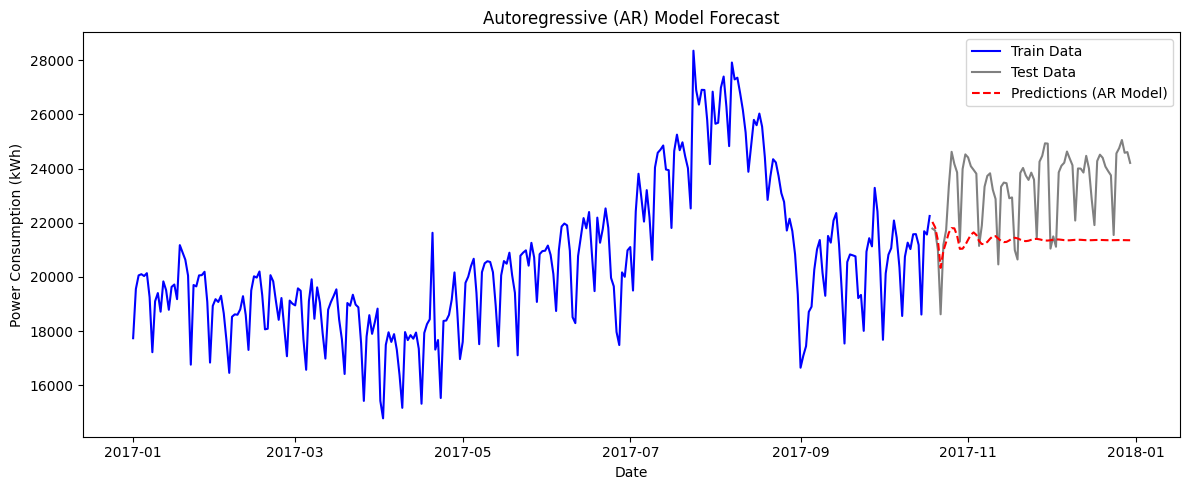

In [ ]:
# AUTOREGRESSION MODEL (AR)
ar_model = AutoReg(train, lags=7).fit()
print(ar_model.summary())

ar_pred = ar_model.predict(start=train_len, end=len(daily_avg)-1, dynamic=False)#predictions

plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_avg.index[:train_len], y=train, label='Train Data', color='blue')
sns.lineplot(x=daily_avg.index[train_len:], y=test, label='Test Data', color='gray')
sns.lineplot(x=daily_avg.index[train_len:], y=ar_pred, label='Predictions (AR Model)', color='red', linestyle='--')
plt.title('Autoregressive (AR) Model Forecast')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

                                 SARIMAX Results                                  
Dep. Variable:     PowerConsumption_Zone2   No. Observations:                  291
Model:                     ARIMA(0, 1, 7)   Log Likelihood               -2467.395
Date:                    Tue, 14 Oct 2025   AIC                           4950.790
Time:                            22:07:10   BIC                           4980.149
Sample:                        01-01-2017   HQIC                          4962.553
                             - 10-18-2017                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2422      0.038     -6.298      0.000      -0.318      -0.167
ma.L2         -0.1711      0.052     -3.289      0.001      -0.273      -0.069
ma.L3         -0.076

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


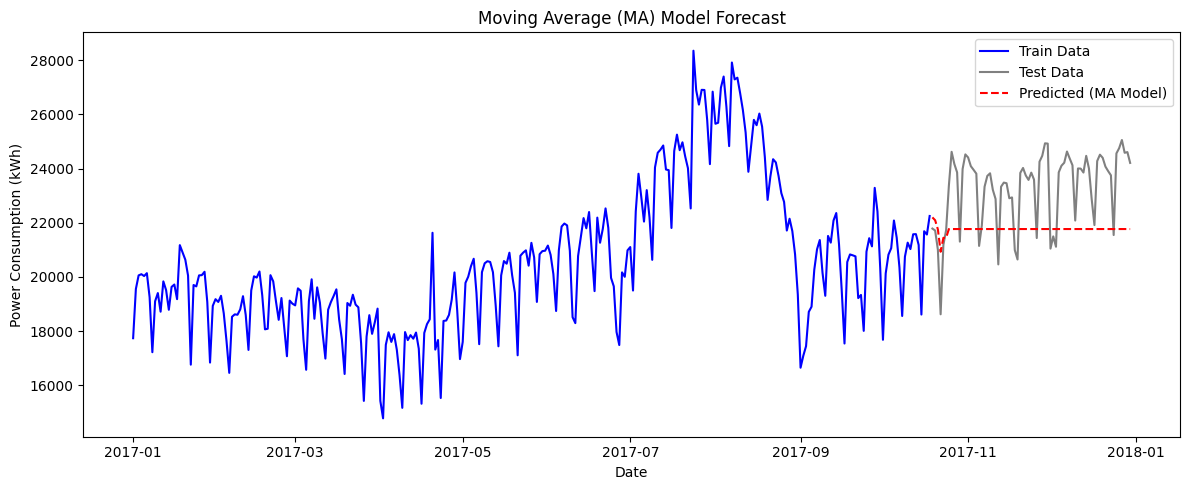

In [ ]:
# MOVING AVERAGE (MA) MODEL
ma_model = ARIMA(train, order=(0, 1, 7)).fit()
print(ma_model.summary())

ma_pred = ma_model.predict(start=train_len, end=len(daily_avg) - 1, typ='levels')

plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_avg.index[:train_len], y=train, label='Train Data', color='blue')
sns.lineplot(x=daily_avg.index[train_len:], y=test, label='Test Data', color='gray')
sns.lineplot(x=daily_avg.index[train_len:], y=ma_pred, label='Predicted (MA Model)', color='red', linestyle='--')
plt.title('Moving Average (MA) Model Forecast')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                 SARIMAX Results                                  
Dep. Variable:     PowerConsumption_Zone2   No. Observations:                  291
Model:                     ARIMA(7, 1, 7)   Log Likelihood               -2406.951
Date:                    Tue, 14 Oct 2025   AIC                           4843.902
Time:                            22:08:10   BIC                           4898.950
Sample:                        01-01-2017   HQIC                          4865.957
                             - 10-18-2017                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0009      0.045     -0.019      0.985      -0.089       0.087
ar.L2         -0.0140      0.046     -0.302      0.763      -0.105       0.077
ar.L3         -0.012

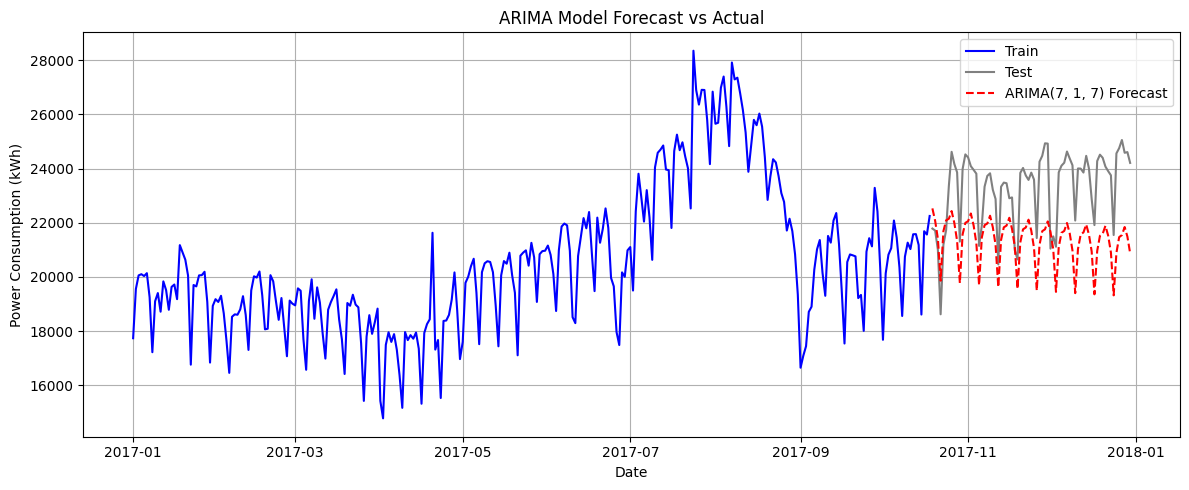

In [ ]:
# ARIMA MODEL
order = (7, 1, 7)
arima_model = ARIMA(train, order=order)
arima_fit = arima_model.fit()

print(arima_fit.summary())
arima_pred = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='gray')
plt.plot(test.index, arima_pred, label=f'ARIMA{order} Forecast', color='red', linestyle='--')
plt.title("ARIMA Model Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Power Consumption (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# checking each models error
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
ma_rmse = np.sqrt(mean_squared_error(test, ma_pred))
ar_rmse = np.sqrt(mean_squared_error(test, ar_pred))
print("ARIMA RMSE:", arima_rmse)
print("MA RMSE:", ma_rmse)
print("AR RMSE:", ar_rmse)

ARIMA RMSE: 2230.991268789374
MA RMSE: 2018.4071537679854
AR RMSE: 2320.3687415854897


                                     SARIMAX Results                                     
Dep. Variable:            PowerConsumption_Zone2   No. Observations:                  291
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2245.247
Date:                           Tue, 14 Oct 2025   AIC                           4500.494
Time:                                   22:12:41   BIC                           4518.560
Sample:                               01-01-2017   HQIC                          4507.745
                                    - 10-18-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0365      0.153     -0.239      0.811      -0.336       0.263
ma.L1         -0.2852      0.138     -2.060

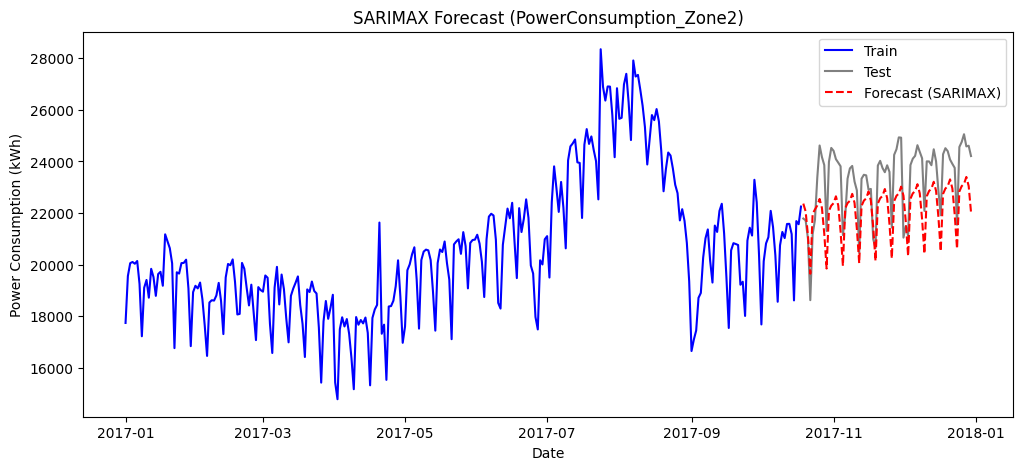

In [ ]:
# EXTRA: SARIMAX Model. Decided to look at this as well since it's more predictive for seasonal data which we thought energy consumption was
# Threw errors when importing pdarima (which was the package used in class), so we used SARIMAX function directly embedded instead

train_data = daily_avg['PowerConsumption_Zone2'][:train_len]
test_data = daily_avg['PowerConsumption_Zone2'][train_len:]

#orders
order = (1, 1, 1)#this is from the ARIMA we did above
seasonal_order = (1, 1, 1, 7)# weekly seasonality for daily data (m=7)

#fit model
import statsmodels.api as sm
sarimax_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=order,
                                          seasonal_order=seasonal_order,
                                          enforce_stationarity=False,
                                          enforce_invertibility=False).fit()

print(sarimax_model.summary())

#forecast
n_periods = len(test_data)
sarimax_pred = sarimax_model.forecast(steps=n_periods)

# evaluate accuracy
sarimax_rmse = np.sqrt(mean_squared_error(test_data, sarimax_pred))
print("SARIMAX RMSE:", sarimax_rmse)

#plot
plt.figure(figsize=(12,5))
sns.lineplot(x=train_data.index, y=train_data, label='Train', color='blue')
sns.lineplot(x=test_data.index, y=test_data, label='Test', color='gray')
sns.lineplot(x=test_data.index, y=sarimax_pred, label='Forecast (SARIMAX)', color='red', linestyle='--')
plt.title('SARIMAX Forecast (PowerConsumption_Zone2)')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.show()
